# Линейная регрессия: построение линии регрессии

## 1. Название и краткая информация о сдаваемом методе в пределах 1 абзаца

**Линейная регрессия** — это метод машинного обучения с учителем, который используется для предсказания числового значения по набору признаков. Суть метода состоит в том, что модель подбирает коэффициенты при признаках так, чтобы получить линейную зависимость между входными данными и целевой переменной. В данной работе линейная регрессия применяется для прогнозирования прочности бетона на сжатие по составу смеси и сроку выдержки. Такой пример удобен для лабораторной работы, потому что целевая переменная числовая, признаков достаточно много, а задача не является слишком примитивной.

## 2. Блок с используемыми библиотеками

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.rcParams["figure.figsize"] = (10, 6)
sns.set_theme(style="whitegrid")

## 3. Блок с описанием и демонстрацией используемого датасета

Используется датасет **Concrete Compressive Strength** — набор данных о составе бетонной смеси и итоговой прочности бетона на сжатие.  
Целевая переменная: **прочность бетона на сжатие**.  
Признаки:
- цемент;
- доменный шлак;
- зола-унос;
- вода;
- суперпластификатор;
- крупный заполнитель;
- мелкий заполнитель;
- возраст бетона в днях.

Ниже выполняется загрузка данных. Сначала программа ищет файл рядом с ноутбуком, а если его нет, пытается скачать его по ссылке.

In [2]:
local_path = Path("Concrete_Data.csv")
url = "https://raw.githubusercontent.com/krameshdn/krameshdn/1ad67512c81f30722831ae3e2290fc853040474a/Concrete_Data.csv"

if local_path.exists():
    df = pd.read_csv(local_path)
else:
    df = pd.read_csv(url)

df.columns = [
    "Цемент",
    "Доменный_шлак",
    "Зола_унос",
    "Вода",
    "Суперпластификатор",
    "Крупный_заполнитель",
    "Мелкий_заполнитель",
    "Возраст_дни",
    "Прочность"
]

print("Размер таблицы:", df.shape)
df.head(10)

Размер таблицы: (1030, 9)


,Цемент,Доменный_шлак,Зола_унос,Вода,Суперпластификатор,Крупный_заполнитель,Мелкий_заполнитель,Возраст_дни,Прочность
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
5,266.0,114.0,0.0,228.0,0.0,932.0,670.0,90,47.03
6,380.0,95.0,0.0,228.0,0.0,932.0,594.0,365,43.70
7,380.0,95.0,0.0,228.0,0.0,932.0,594.0,28,36.45
8,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.85
9,475.0,0.0,0.0,228.0,0.0,932.0,594.0,28,39.29


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Цемент               1030 non-null   float64
 1   Доменный_шлак        1030 non-null   float64
 2   Зола_унос            1030 non-null   float64
 3   Вода                 1030 non-null   float64
 4   Суперпластификатор   1030 non-null   float64
 5   Крупный_заполнитель  1030 non-null   float64
 6   Мелкий_заполнитель   1030 non-null   float64
 7   Возраст_дни          1030 non-null   int64  
 8   Прочность            1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [4]:
df.describe().round(2)

,Цемент,Доменный_шлак,Зола_унос,Вода,Суперпластификатор,Крупный_заполнитель,Мелкий_заполнитель,Возраст_дни,Прочность
count,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00
mean,281.17,73.90,54.19,181.57,6.20,972.92,773.58,45.66,35.82
std,104.51,86.28,64.00,21.35,5.97,77.75,80.18,63.17,16.71
min,102.00,0.00,0.00,121.80,0.00,801.00,594.00,1.00,2.33
25%,192.38,0.00,0.00,164.90,0.00,932.00,730.95,7.00,23.71
50%,272.90,22.00,0.00,185.00,6.40,968.00,779.50,28.00,34.44
75%,350.00,142.95,118.30,192.00,10.20,1029.40,824.00,56.00,46.14
max,540.00,359.40,200.10,247.00,32.20,1145.00,992.60,365.00,82.60


## 4. Блок с предварительной обработкой датасета

На этом этапе:
1. проверяем пропуски;
2. выделяем признаки и целевую переменную;
3. делим данные на обучающую и тестовую части;
4. создаём конвейер обработки данных.

**Конвейер** — это последовательность действий, которая автоматически выполняет подготовку данных и обучение модели в правильном порядке.  
В данной работе для числовых признаков используются:
- заполнение пропусков медианой;
- стандартизация.

**Стандартизация** — это приведение признаков к сопоставимому масштабу, чтобы значения с большими единицами измерения не доминировали над остальными.

In [3]:
print("Количество пропусков по столбцам:")
print(df.isnull().sum())

Количество пропусков по столбцам:
Цемент                 0
Доменный_шлак          0
Зола_унос              0
Вода                   0
Суперпластификатор     0
Крупный_заполнитель    0
Мелкий_заполнитель     0
Возраст_дни            0
Прочность              0
dtype: int64


In [4]:
X = df.drop("Прочность", axis=1)
y = df["Прочность"]

numeric_features = X.columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("заполнение_пропусков", SimpleImputer(strategy="median")),
    ("стандартизация", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("числовые_признаки", numeric_transformer, numeric_features)
    ],
    remainder="drop"
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

Размер обучающей выборки: (824, 8)
Размер тестовой выборки: (206, 8)


## 5. Блок с тепловой картой

Тепловая карта показывает коэффициенты корреляции между признаками и целевой переменной.  
**Корреляция** — это показатель силы и направления линейной связи между величинами.

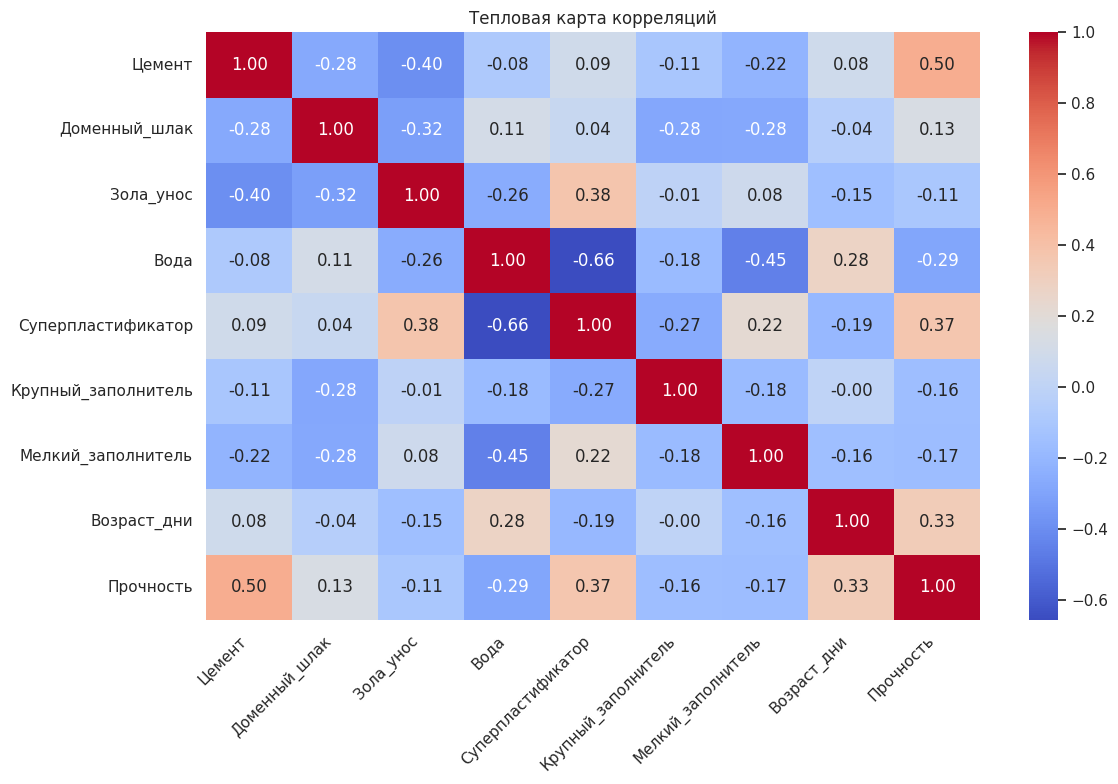

In [7]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=False)
plt.title("Тепловая карта корреляций")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Блок с обучением модели

Создаём итоговый конвейер: сначала выполняется подготовка данных, затем обучается модель линейной регрессии.

In [5]:
model = Pipeline(steps=[
    ("предобработка", preprocessor),
    ("модель", LinearRegression())
])

model.fit(X_train, y_train)

print("Модель обучена.")

Модель обучена.


In [6]:
linear_model = model.named_steps["модель"]

coefficients = pd.DataFrame({
    "Признак": numeric_features,
    "Коэффициент": linear_model.coef_
}).sort_values(by="Коэффициент", ascending=False)

coefficients

,Признак,Коэффициент
0,Цемент,12.788413
1,Доменный_шлак,9.434456
7,Возраст_дни,7.037434
2,Зола_унос,5.254578
6,Мелкий_заполнитель,1.950529
4,Суперпластификатор,1.852126
5,Крупный_заполнитель,1.405196
3,Вода,-2.882597


## 7. Блок с прогнозами модели

После обучения модель строит прогнозы для тестовой выборки. Затем сравниваем реальные и предсказанные значения.

In [7]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "Реальное_значение": y_test.values,
    "Предсказанное_значение": np.round(y_pred, 2)
})

comparison.head(15)

,Реальное_значение,Предсказанное_значение
0,52.91,59.66
1,55.90,52.04
2,74.50,63.54
3,35.30,51.58
4,10.54,17.22
5,44.28,39.87
6,23.69,26.70
7,45.37,44.74
8,37.40,29.37
9,48.85,38.19


In [11]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"MSE  (средняя квадратичная ошибка): {mse:.3f}")
print(f"RMSE (корень из средней квадратичной ошибки): {rmse:.3f}")
print(f"MAE  (средняя абсолютная ошибка): {mae:.3f}")
print(f"R²   (коэффициент детерминации): {r2:.3f}")

MSE  (средняя квадратичная ошибка): 95.971
RMSE (корень из средней квадратичной ошибки): 9.796
MAE  (средняя абсолютная ошибка): 7.746
R²   (коэффициент детерминации): 0.628


## 8. Блок с графиками выходных результатов

Ниже строятся основные графики:
1. сравнение реальных и предсказанных значений;
2. график остатков;
3. распределение ошибок.

**Остаток** — это разница между реальным и предсказанным значением.

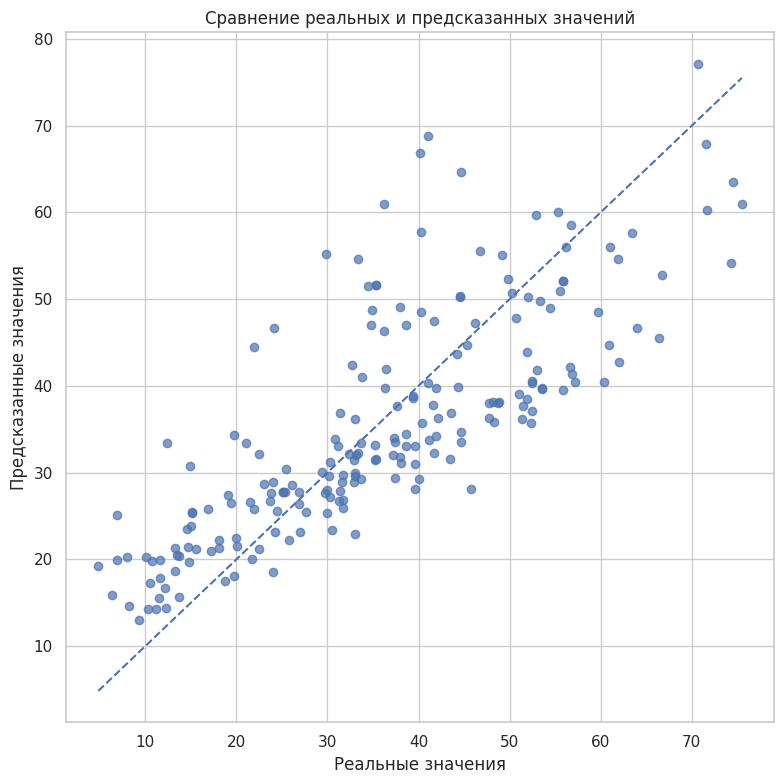

In [12]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
plt.xlabel("Реальные значения")
plt.ylabel("Предсказанные значения")
plt.title("Сравнение реальных и предсказанных значений")
plt.tight_layout()
plt.show()

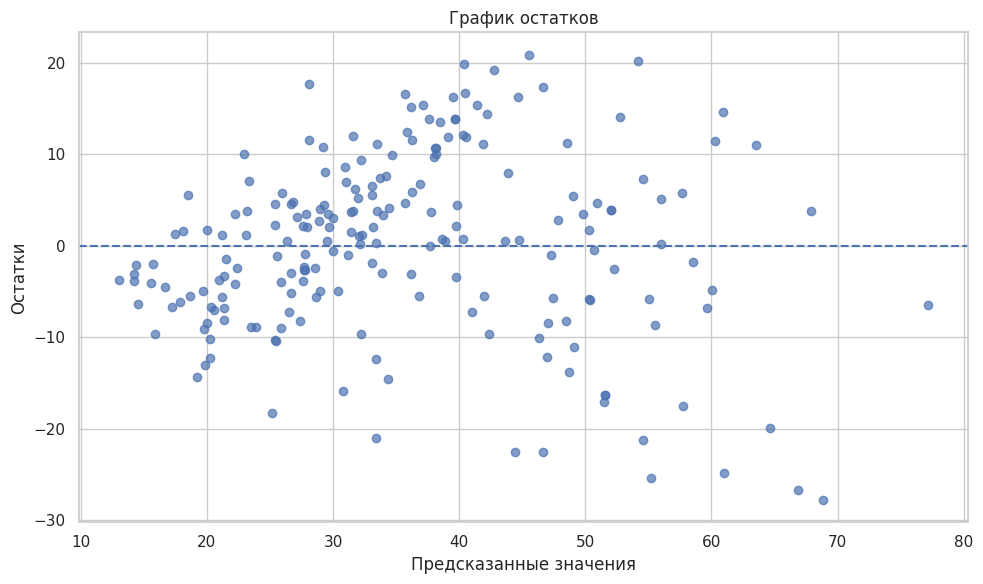

In [13]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Предсказанные значения")
plt.ylabel("Остатки")
plt.title("График остатков")
plt.tight_layout()
plt.show()

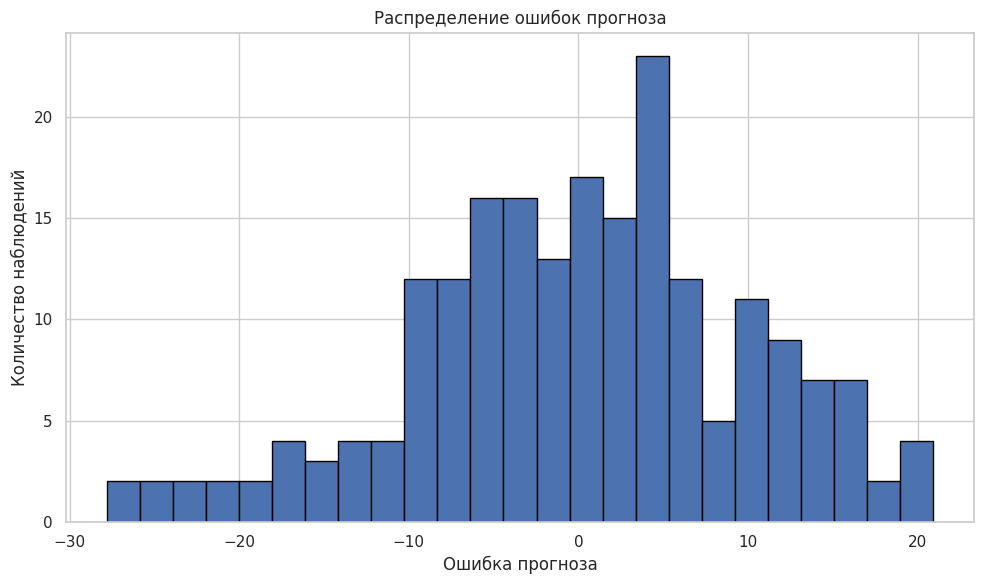

In [14]:
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=25, edgecolor="black")
plt.xlabel("Ошибка прогноза")
plt.ylabel("Количество наблюдений")
plt.title("Распределение ошибок прогноза")
plt.tight_layout()
plt.show()

## Итоговый вывод

В ходе работы была построена модель линейной регрессии для прогнозирования прочности бетона на сжатие по нескольким признакам. Были выполнены загрузка и анализ датасета, предварительная обработка данных, построение тепловой карты, обучение модели, получение прогнозов и визуализация результатов. Линейная регрессия показала адекватное качество на многопризнаковом датасете и позволяет наглядно продемонстрировать принцип построения линии регрессии в задаче численного прогноза.